# Bank Churn

### Install Lazy predict

In [61]:
!pip install lazypredict

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.0/29.0 MB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 57.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 692.3/692.3 kB 50.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.4/203.4 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 7.4 MB/s eta 0:00:00


In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate
from google.colab import files
uploaded = files.upload()

Saving Customer-Churn-Records-2.csv to Customer-Churn-Records-2 (1).csv


Import packages

# Data Cleaning

In [82]:
df = pd.read_csv('Customer-Churn-Records-2.csv')
df.shape

(10000, 18)

Load in the dataframe and see the number of rows/columns.

In [83]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited', 'Complain',
       'Satisfaction Score', 'Card Type', 'Point Earned'],
      dtype='object')

See a list of the names of each column.

In [84]:
print(df['Card Type'].unique())

['DIAMOND' 'GOLD' 'SILVER' 'PLATINUM']


In [86]:
from sklearn.preprocessing import LabelEncoder
# Step 1: Drop unnecessary columns
df.drop(['RowNumber', 'CustomerId', 'Surname', 'Geography','Complain'], axis=1, inplace=True)

# Step 2: Initialize LabelEncoder
le = LabelEncoder()

# Step 3: Apply Label Encoding to specific columns
df['Gender'] = le.fit_transform(df['Gender'])
df['Card Type'] = le.fit_transform(df['Card Type'])

# Step 4: Preview
df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Satisfaction Score,Card Type,Point Earned
0,619,0,42,2,0.00,1,1,1,101348.88,1,2,0,464
1,608,0,41,1,83807.86,1,0,1,112542.58,0,3,0,456
2,502,0,42,8,159660.80,3,1,0,113931.57,1,3,0,377
3,699,0,39,1,0.00,2,0,0,93826.63,0,5,1,350
4,850,0,43,2,125510.82,1,1,1,79084.10,0,5,1,425


Use one-hot encoding to change gender to binary, and card type to a categorical integer instead of string.

In [87]:
df.tail()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Satisfaction Score,Card Type,Point Earned
9995,771,1,39,5,0.00,2,1,0,96270.64,0,1,0,300
9996,516,1,35,10,57369.61,1,1,1,101699.77,0,5,2,771
9997,709,0,36,7,0.00,1,0,1,42085.58,1,3,3,564
9998,772,1,42,3,75075.31,2,1,0,92888.52,1,2,1,339
9999,792,0,28,4,130142.79,1,1,0,38190.78,0,3,0,911


See the last 5 rows of the dataframe.

In [88]:
df.describe()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Satisfaction Score,Card Type,Point Earned
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,650.528800,0.545700,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203800,3.013800,1.498000,606.515100
std,96.653299,0.497932,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402842,1.405919,1.118356,225.924839
min,350.000000,0.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,1.000000,0.000000,119.000000
25%,584.000000,0.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,2.000000,0.000000,410.000000
50%,652.000000,1.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,3.000000,1.000000,605.000000
75%,718.000000,1.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000,4.000000,2.000000,801.000000
max,850.000000,1.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,5.000000,3.000000,1000.000000


See descriptive statistics for each column of the dataframe.

# Visualizing Descriptive Statistics

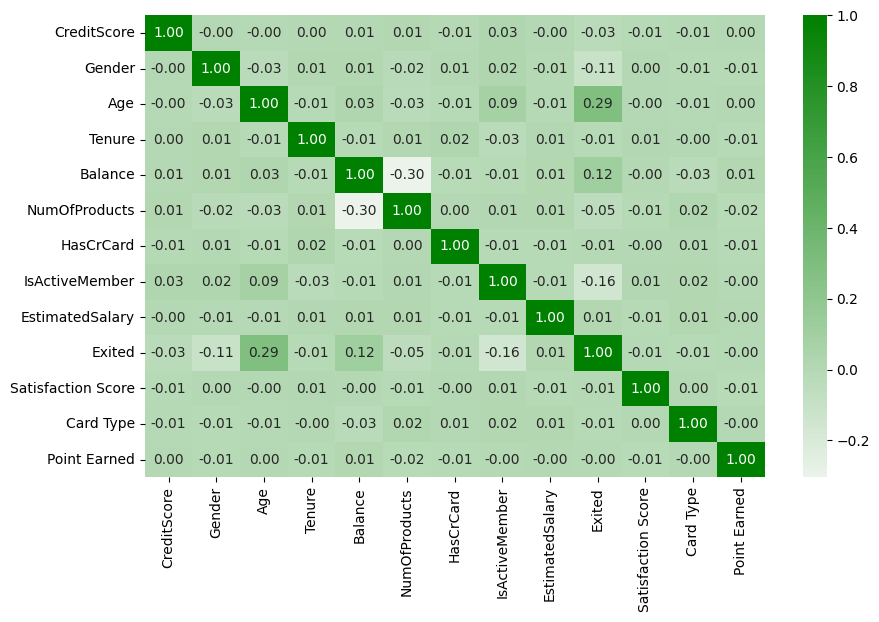

In [89]:
cm = df.corr(numeric_only=True)
plt.figure(figsize=(10,6))
sns.heatmap(cm, annot=True, cmap=sns.light_palette("green", as_cmap=True), fmt=".2f")
plt.show()

Create a correlation matrix to see the strength of linear relationships between the features of the dataset.

In [90]:
fig1 = px.histogram(df,x = 'Exited',text_auto=True,title='Class Distribution')
fig1.update_layout(bargap=0.4,
                   xaxis=dict(type='category'),
                   showlegend=True
                  )
fig1.update_traces(marker_color=['#808080', '#000000'])
fig1.show()

A histogram that shows the distribution of the target variable (Exited).

In [91]:
df[df.isnull().any(axis=1)]

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Satisfaction Score,Card Type,Point Earned


Use this to check for any missing values in the dataset, and it is observable that none are present.

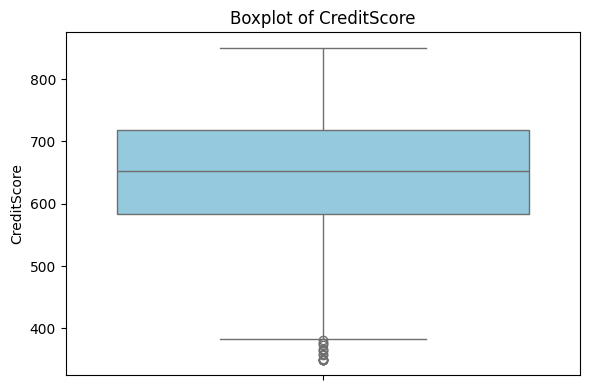

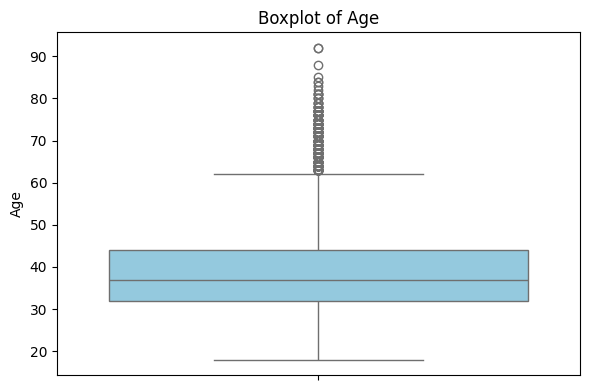

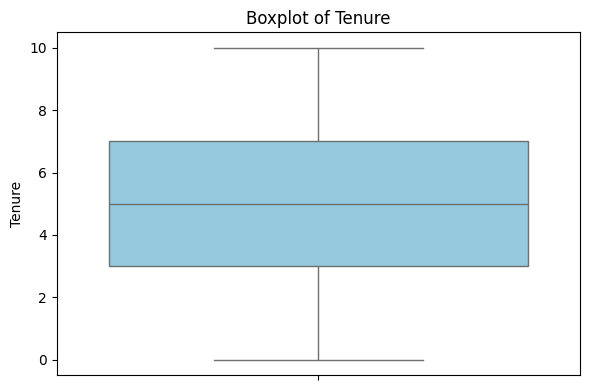

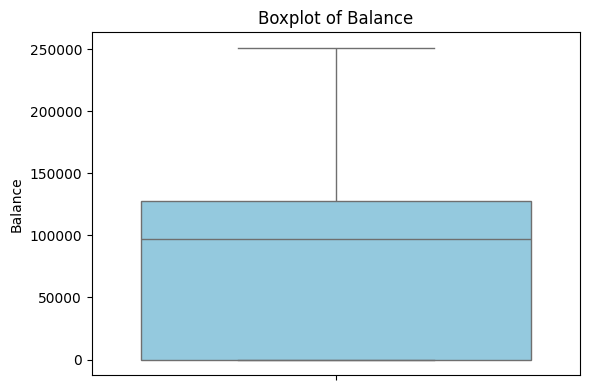

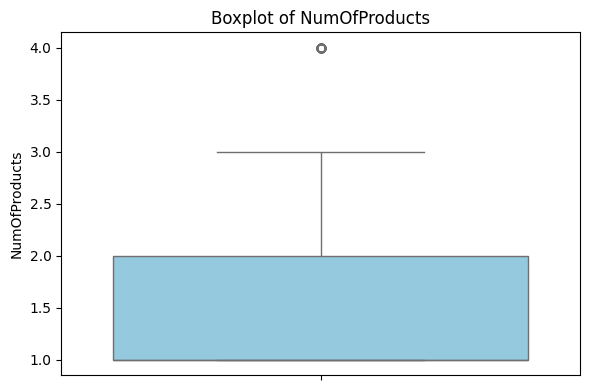

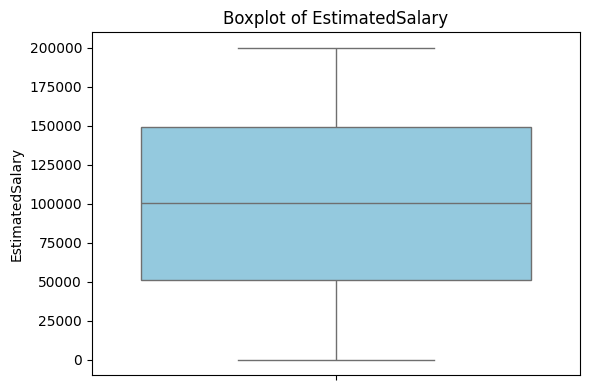

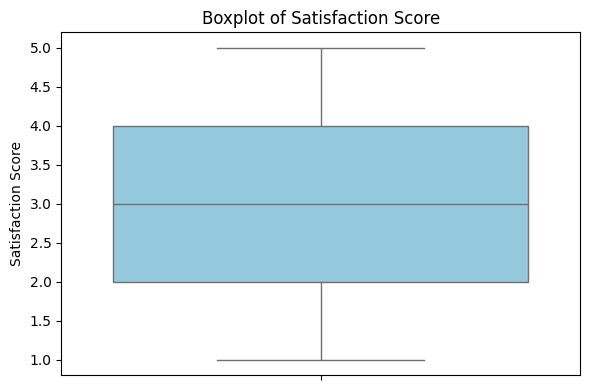

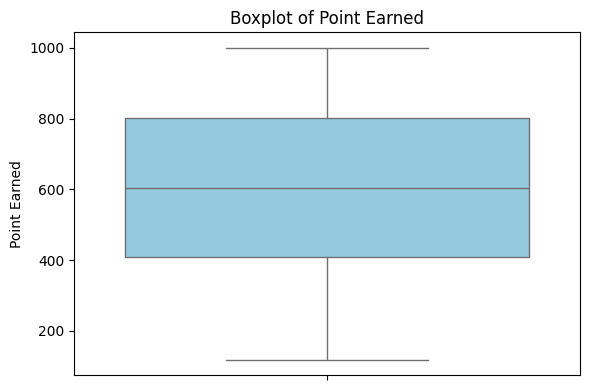

In [93]:
distribution_df = df.drop(['Gender',
                           'HasCrCard',
                           'IsActiveMember',
                           'Exited',
                           'Card Type'],
                          axis=1)

for col in distribution_df.columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Boxplot of {col}')
    plt.tight_layout()
    plt.show()

A box plot of each numeri feature was created in order to see the distribution and determine whether any outliers/incorrect values exist.

In [94]:
fig1 = px.histogram(df,x = 'Age',title='Age Distribution')
fig1.update_layout(bargap=0.1)
fig1.show()

This shows a distribution of the age column.

# Model Selection

In [95]:
from lazypredict.Supervised import LazyClassifier
from sklearn.model_selection import train_test_split

X = df.drop("Exited", axis=1)
y = df["Exited"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = LazyClassifier(verbose=0, ignore_warnings=True)
models, predictions = clf.fit(X_train, X_test, y_train, y_test)

print(models)

  0%|          | 0/32 [00:00<?, ?it/s]

[LightGBM] [Info] Number of positive: 1645, number of negative: 6355
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002013 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1122
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.205625 -> initscore=-1.351502
[LightGBM] [Info] Start training from score -1.351502
                               Accuracy  Balanced Accuracy  ROC AUC  F1 Score  \
Model                                                                           
XGBClassifier                      0.85               0.71     0.71      0.84   
AdaBoostClassifier                 0.85               0.71     0.71      0.84   
LGBMClassifier                     0.86               0.70     0.70      0.84   
NearestCentroid                    0.70 

Using the lazy classifier package, we are able to determine which model type best fits the dataset and provides the greatest metrics. We utilized this to determine that AdaBoost will be our choice for classification modeling the churn data.

# Holdout Partition

In [96]:
positive = df[df['Exited']==1]
negative = df[df['Exited']==0]

positive_holdout = positive.sample(frac=0.15,random_state=42)
negative_holdout = negative.sample(frac=0.15,random_state=42)

holdout = pd.concat([positive_holdout,negative_holdout])

X_holdout = holdout.drop('Exited',axis=1)
y_holdout = holdout['Exited']
traintest = df.drop(holdout.index)

X_train = traintest.drop('Exited',axis=1)
y_train = traintest['Exited']

We created a holdout partition of 15% of the original data to test the model on later, as well as creating the training data objects.

We used a parameter search to find the best hyperparameters to use in the model, using a 7-fold cross validation as the dataset is larger.

# Model Fitting/Scoring

## AdaBoost

### Parameter Optimization

In [97]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

adaboost = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(),
    random_state=42
)

param_grid = {
    'n_estimators': [10, 50, 100],
    'learning_rate': [0.01, 0.1, 1],
    'estimator__max_depth': [1, 3, 5]
}

grid_search = GridSearchCV(
    estimator=adaboost,
    param_grid=param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=3
)

grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 27 candidates, totalling 81 fits


GridSearchCV(cv=3,
             estimator=AdaBoostClassifier(estimator=DecisionTreeClassifier(),
                                          random_state=42),
             n_jobs=-1,
             param_grid={'estimator__max_depth': [1, 3, 5],
                         'learning_rate': [0.01, 0.1, 1],
                         'n_estimators': [10, 50, 100]},
             scoring='f1', verbose=3)

### Model Fitting/Scoring

In [125]:
print("Best parameters for AdaBoost:")
print(grid_search.best_params_)

Best parameters for AdaBoost:
{'estimator__max_depth': 5, 'learning_rate': 1, 'n_estimators': 50}


In [98]:
from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score, accuracy_score, log_loss

best_ad = grid_search.best_estimator_
best_ad.fit(X_train,y_train)

yhat_ad = best_ad.predict(X_holdout)
yhat_prob = best_ad.predict_proba(X_holdout)

f1_ad = f1_score(y_holdout, yhat_ad)
auc_ad = roc_auc_score(y_holdout, yhat_prob[:, 1])
precision_ad = precision_score(y_holdout, yhat_ad)
recall_ad = recall_score(y_holdout, yhat_ad)
accuracy_ad = accuracy_score(y_holdout, yhat_ad)
log_loss_ad = log_loss(y_holdout, yhat_prob)

print(f"Holdout F1 Score: {round(f1_ad * 100, 2)}%")
print(f"Holdout AUC: {round(auc_ad * 100, 2)}%")
print(f"Holdout Precision: {round(precision_ad * 100, 2)}%")
print(f"Holdout Recall: {round(recall_ad * 100, 2)}%")
print(f"Holdout Accuracy: {round(accuracy_ad * 100, 2)}%")
print(f"Holdout Log Loss: {round(log_loss_ad, 4)}")

Holdout F1 Score: 49.3%
Holdout AUC: 82.45%
Holdout Precision: 63.73%
Holdout Recall: 40.2%
Holdout Accuracy: 83.13%
Holdout Log Loss: 0.5008


This fits the best parameters from above to the final AdaBoost model, and then prints out various metrics such as the F1 score, AUC, accuracy, and logloss.

## K-Nearest-Neighbor

### Parameter Optimization

In [99]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
param_grid_knn = {
    'n_neighbors':[1,2,3,4,5,10],
    'weights':['uniform','distance'],
    'metric':['euclidean','manhattan']
}
grid_search_knn = GridSearchCV(estimator=knn,
                              param_grid=param_grid_knn,
                              cv=4,
                              scoring='f1')
grid_search_knn.fit(X_train,y_train)

GridSearchCV(cv=4, estimator=KNeighborsClassifier(),
             param_grid={'metric': ['euclidean', 'manhattan'],
                         'n_neighbors': [1, 2, 3, 4, 5, 10],
                         'weights': ['uniform', 'distance']},
             scoring='f1')

### Model Fitting/Scoring

In [100]:
best_knn = grid_search_knn.best_estimator_
best_knn.fit(X_train,y_train)
print(grid_search_knn.best_params_)

{'metric': 'manhattan', 'n_neighbors': 1, 'weights': 'uniform'}


In [101]:
from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score, accuracy_score, log_loss

knn_probabilities = best_knn.predict_proba(X_holdout)[:, 1]
yhat_knn = best_knn.predict(X_holdout)

f1_knn = f1_score(y_holdout, yhat_knn)
auc_knn = roc_auc_score(y_holdout, knn_probabilities)
precision_knn = precision_score(y_holdout, yhat_knn)
recall_knn = recall_score(y_holdout, yhat_knn)
accuracy_knn = accuracy_score(y_holdout, yhat_knn)
logloss_knn = log_loss(y_holdout, knn_probabilities)

print('Holdout F1 Score: {:.2%}'.format(f1_knn))
print('Holdout AUC: {:.2%}'.format(auc_knn))
print('Holdout Precision: {:.2%}'.format(precision_knn))
print('Holdout Recall: {:.2%}'.format(recall_knn))
print('Holdout Accuracy: {:.2%}'.format(accuracy_knn))
print('Holdout Log Loss: {:.4f}'.format(logloss_knn))

Holdout F1 Score: 21.57%
Holdout AUC: 51.46%
Holdout Precision: 23.05%
Holdout Recall: 20.26%
Holdout Accuracy: 69.93%
Holdout Log Loss: 10.8371


## Random Forest

### Parameter Optimization

In [119]:
rf = RandomForestClassifier(random_state=42)

param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}

grid_search_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    cv=2,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search_rf.fit(X_train, y_train)

Fitting 2 folds for each of 108 candidates, totalling 216 fits


GridSearchCV(cv=2, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 5, 10, 20],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             scoring='f1', verbose=1)

### Model Fitting/Scoring

In [120]:
best_rf = grid_search_rf.best_estimator_
best_rf.fit(X_train, y_train)
print(grid_search_rf.best_params_)

{'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 50}


In [121]:
from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score, accuracy_score, log_loss

rf_probabilities = best_rf.predict_proba(X_holdout)[:, 1]
yhat_rf = best_rf.predict(X_holdout)

f1_rf = f1_score(y_holdout, yhat_rf)
auc_rf = roc_auc_score(y_holdout, rf_probabilities)
precision_rf = precision_score(y_holdout, yhat_rf)
recall_rf = recall_score(y_holdout, yhat_rf)
accuracy_rf = accuracy_score(y_holdout, yhat_rf)
logloss_rf = log_loss(y_holdout, rf_probabilities)

print('Holdout F1 Score (Random Forest): {:.2%}'.format(f1_rf))
print('Holdout AUC (Random Forest): {:.2%}'.format(auc_rf))
print('Holdout Precision (Random Forest): {:.2%}'.format(precision_rf))
print('Holdout Recall (Random Forest): {:.2%}'.format(recall_rf))
print('Holdout Accuracy (Random Forest): {:.2%}'.format(accuracy_rf))
print('Holdout Log Loss (Random Forest): {:.4f}'.format(logloss_rf))

Holdout F1 Score (Random Forest): 52.47%
Holdout AUC (Random Forest): 82.42%
Holdout Precision (Random Forest): 76.73%
Holdout Recall (Random Forest): 39.87%
Holdout Accuracy (Random Forest): 85.27%
Holdout Log Loss (Random Forest): 0.4127


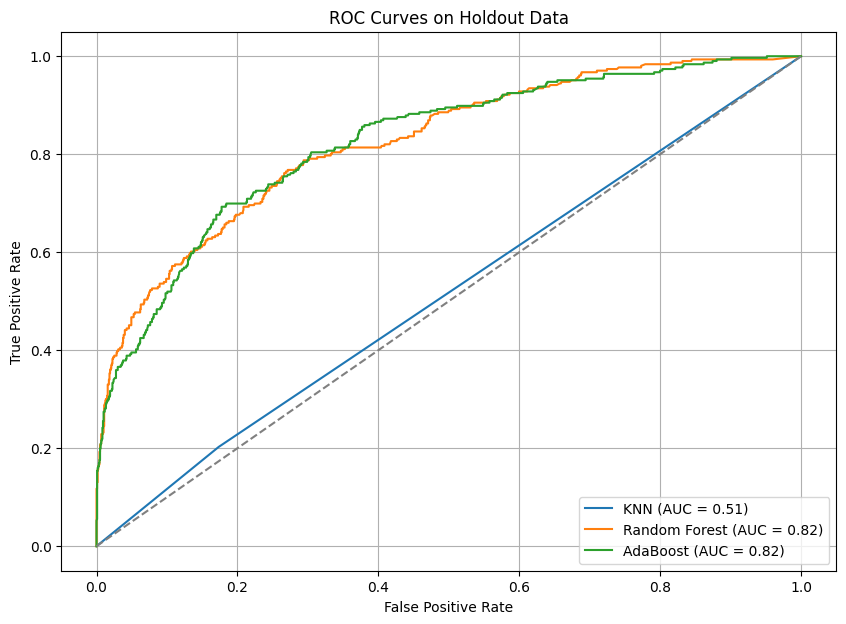

In [124]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

knn_probs = best_knn.predict_proba(X_holdout)[:, 1]
rf_probs = best_rf.predict_proba(X_holdout)[:, 1]
ad_probs = best_ad.predict_proba(X_holdout)[:, 1]

fpr_knn, tpr_knn, _ = roc_curve(y_holdout, knn_probs)
fpr_rf, tpr_rf, _ = roc_curve(y_holdout, rf_probs)
fpr_ad, tpr_ad, _ = roc_curve(y_holdout, ad_probs)

auc_knn = roc_auc_score(y_holdout, knn_probs)
auc_rf = roc_auc_score(y_holdout, rf_probs)
auc_ad = roc_auc_score(y_holdout, ad_probs)

plt.figure(figsize=(10, 7))
plt.plot(fpr_knn, tpr_knn, label='KNN (AUC = {:.2f})'.format(auc_knn))
plt.plot(fpr_rf, tpr_rf, label='Random Forest (AUC = {:.2f})'.format(auc_rf))
plt.plot(fpr_ad, tpr_ad, label='AdaBoost (AUC = {:.2f})'.format(auc_ad))

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Diagonal reference line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves on Holdout Data')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Findings/Conclusion

Of the three models tested above, we were able to determine that the AdaBoost and random forest models are the much better options. KNN has AUC = 0.51 which is close to guessing.

## Feature Importance

In [102]:
X = df.drop(columns = ['Exited'])
y = df['Exited']

model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(),
    random_state=42)
model.fit(X, y)

AdaBoostClassifier(estimator=DecisionTreeClassifier(), random_state=42)

In [103]:
feature_importance = model.feature_importances_
feature_importance_sorted_idx = np.argsort(feature_importance)[::-1]
for idx in feature_importance_sorted_idx:
    print(f"{X.columns[idx]}: {feature_importance[idx]:.4f}")

Age: 0.2136
EstimatedSalary: 0.1237
Point Earned: 0.1217
NumOfProducts: 0.1172
Balance: 0.1117
CreditScore: 0.1106
Tenure: 0.0614
IsActiveMember: 0.0555
Satisfaction Score: 0.0342
Card Type: 0.0301
Gender: 0.0119
HasCrCard: 0.0084


In [104]:
I = model.feature_importances_

In [105]:
I

array([0.1105754 , 0.01191432, 0.21359306, 0.06143865, 0.11167918,
       0.11718812, 0.00841489, 0.05548694, 0.12372039, 0.03420625,
       0.03012532, 0.12165747])

In [110]:
df.columns

Index(['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
       'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited',
       'Satisfaction Score', 'Card Type', 'Point Earned'],
      dtype='object')

In [113]:
name_features = df.drop('Exited',axis = 1).columns.tolist()

In [114]:
len(name_features)

12

In [115]:
len(I)

12

In [116]:
df_I=pd.DataFrame([I, name_features])
df_I

,0,1,2,3,4,5,6,7,8,9,10,11
0,0.11,0.01,0.21,0.06,0.11,0.12,0.01,0.06,0.12,0.03,0.03,0.12
1,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Satisfaction Score,Card Type,Point Earned


<Axes: xlabel='Importance', ylabel='Feature'>

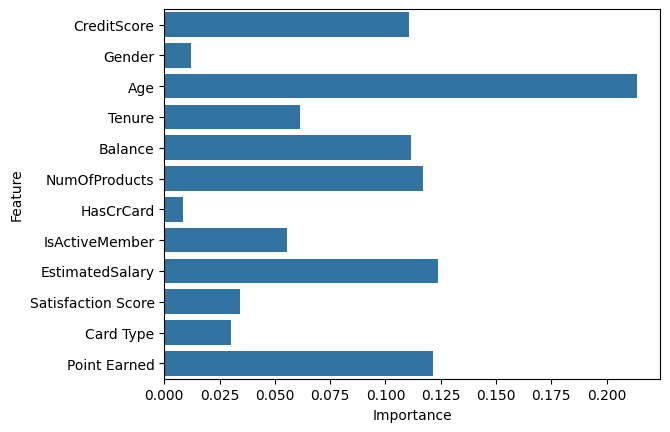

In [117]:
df_plot = pd.DataFrame({"Feature": name_features, "Importance": I})
sns.barplot(data=df_plot, x="Importance", y="Feature")

Age is the most important feature when we consider Adaboost model. As the Age increases the person is more likely to churn.